[2026-07-08 15:34:35] [info     ] 因子完成: 240201条, 242天
[2026-07-08 15:34:35] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-08 15:34:38] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-08 15:34:39] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-08 15:34:40] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-08 15:34:40] [info     ] ========== 数据检查 ==========
[2026-07-08 15:34:40] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netf

时段,IC
2024-01-15~2024-02-08,0.0029
2024-09-24~2024-10-08,-0.0224

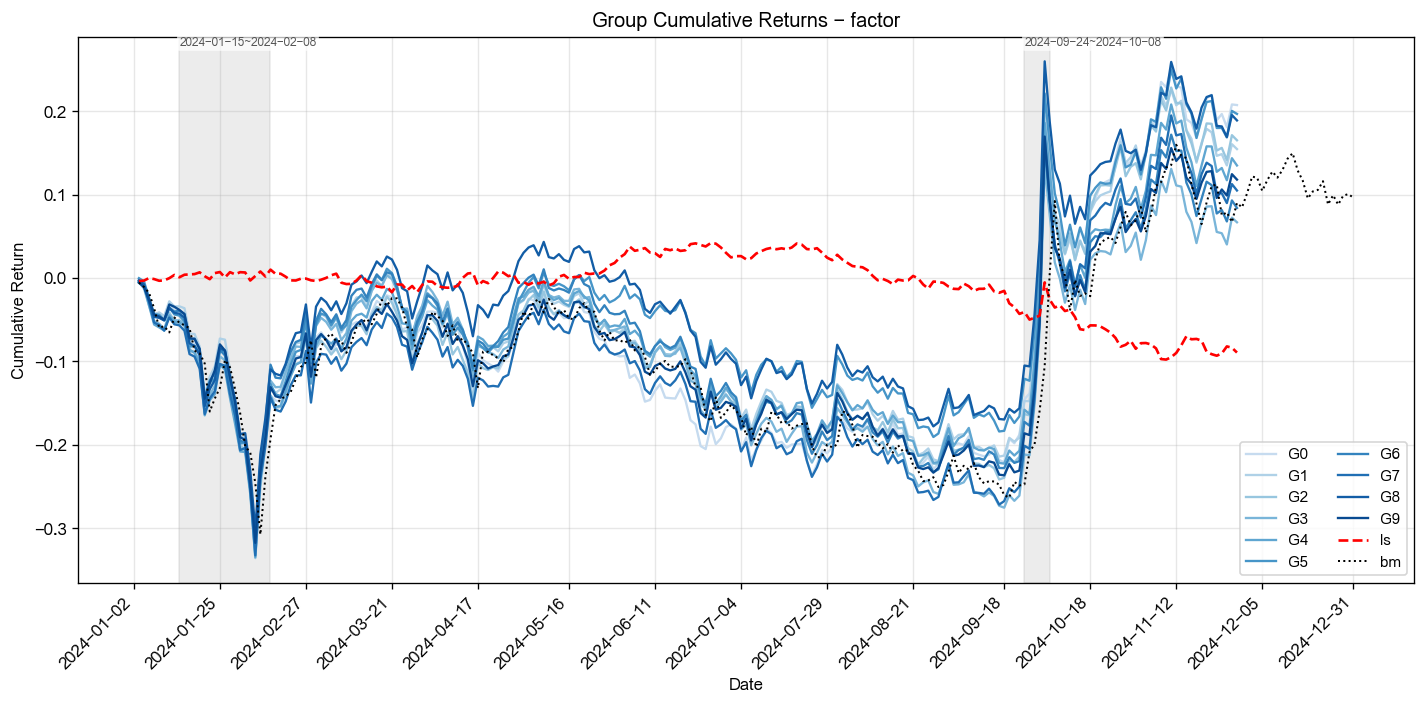
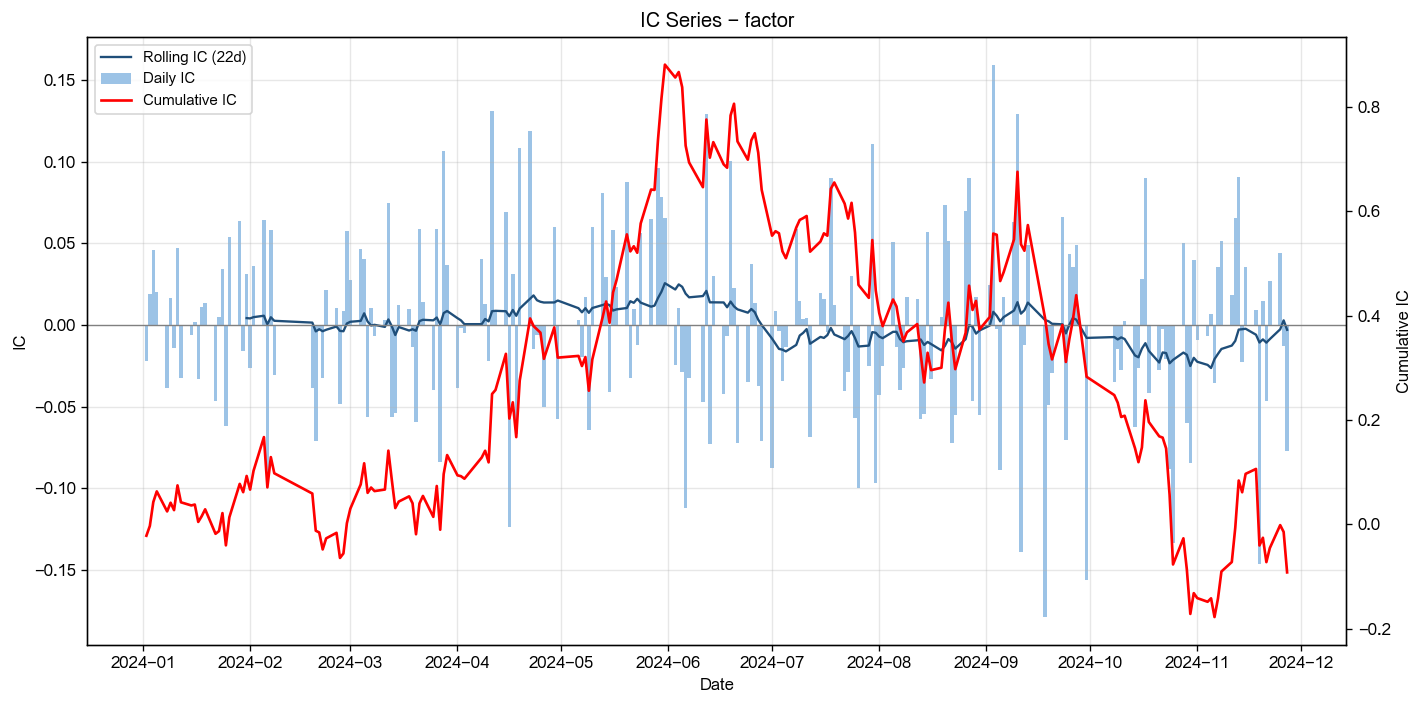
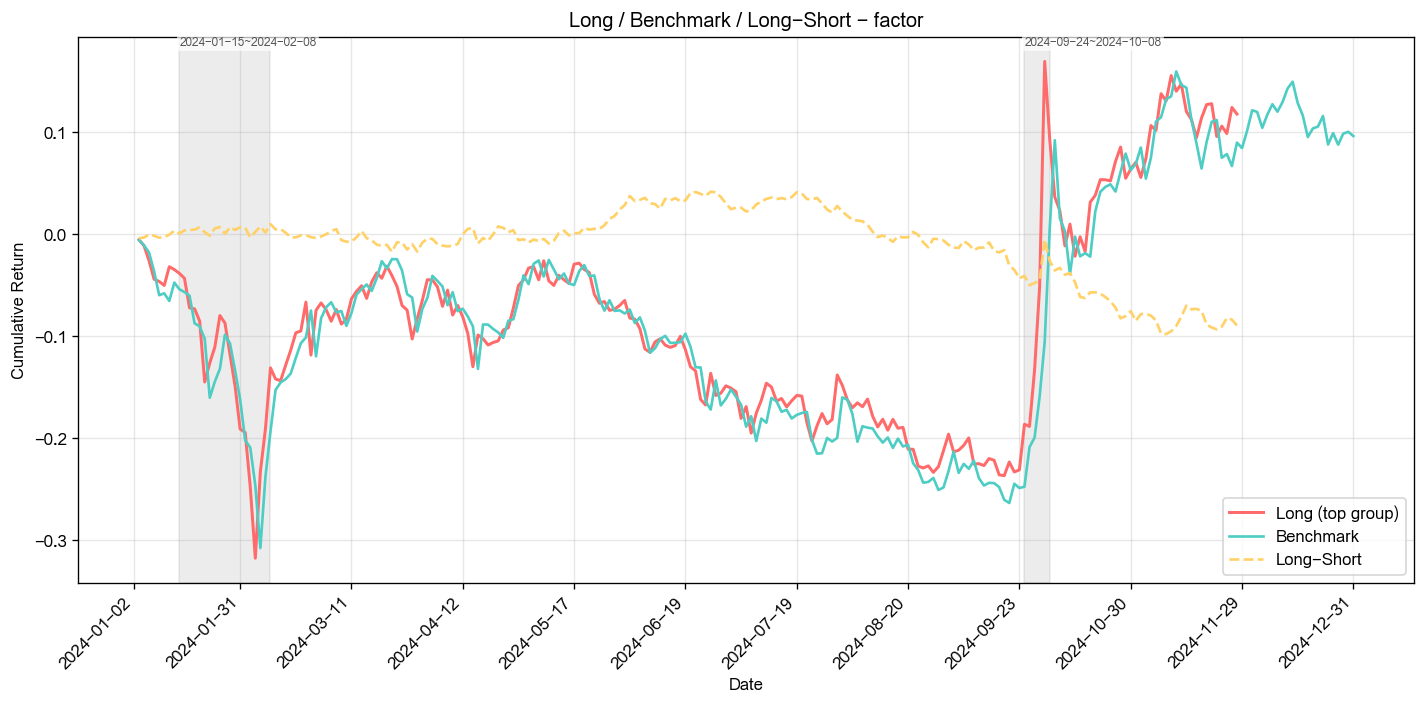
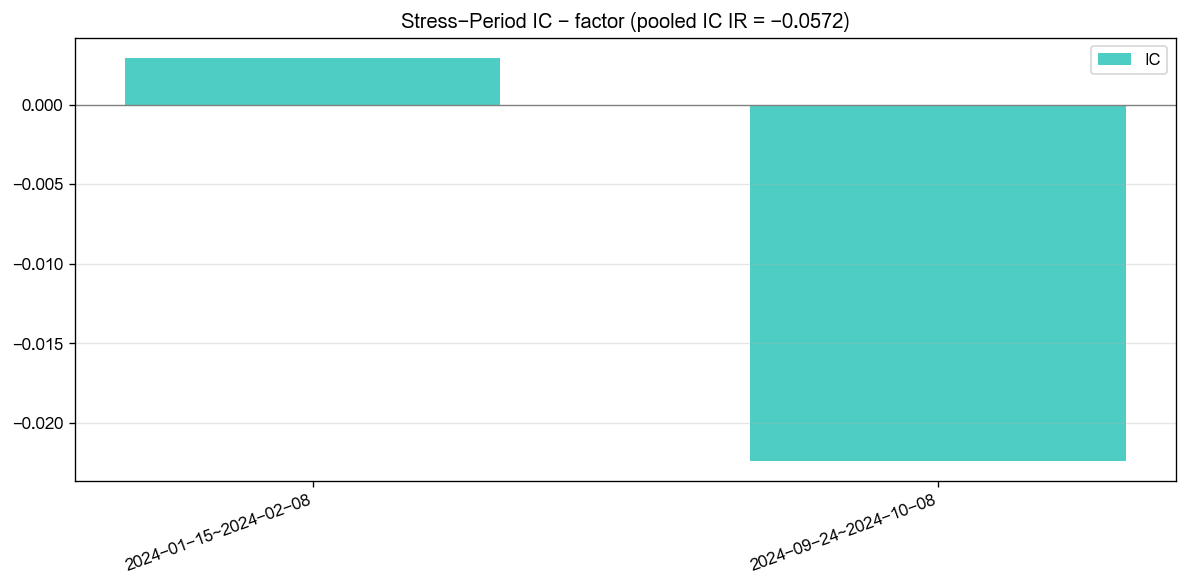
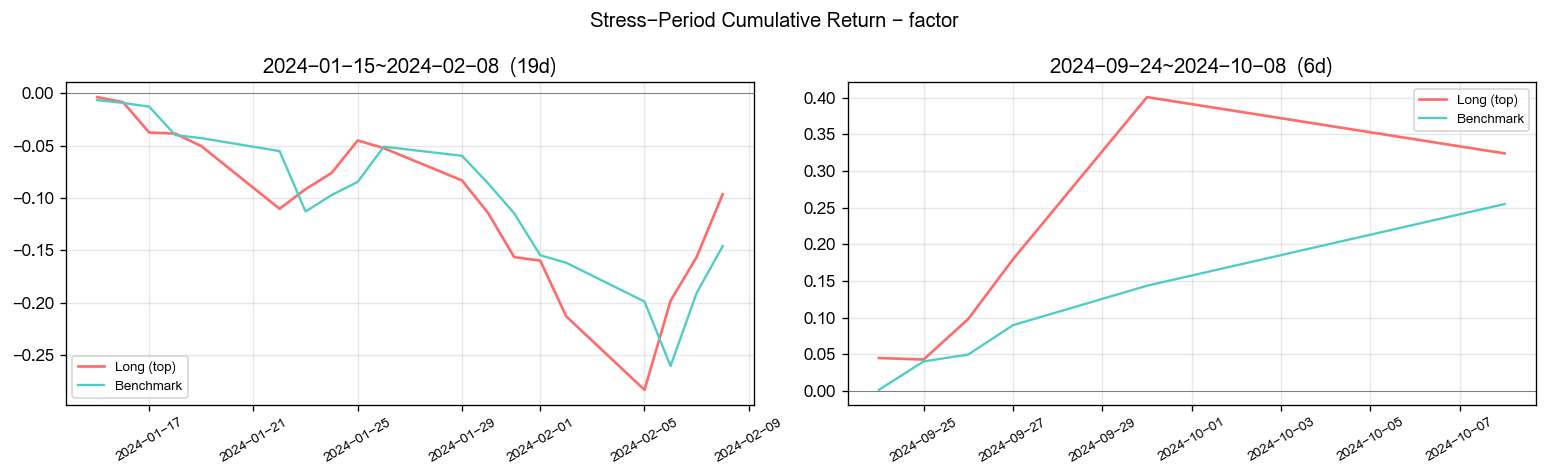

[2026-07-08 15:36:03] [info     ] ========== 因子池回归 ==========
[2026-07-08 15:36:03] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-08 15:36:06] [info     ] 获取收益率数据, 耗时: 2.7634 秒
[2026-07-08 15:36:08] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.1436 秒
[2026-07-08 15:36:08] [info     ] 统计 回归结果, 耗时: 0.0076 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9139,0.0448,0.0234,1.0000
2,amount,1.8783,0.0191,0.0101,1.0000
3,netflow_amount_rate_main,1.6102,0.0094,0.0058,1.0000
4,gross_profit_rate_ttm,1.5050,0.0070,0.0046,0.9000
5,factor,1.4970,0.0078,0.0052,0.9000
6,netflow_amount_main,1.4726,0.0225,0.0153,1.0000
7,net_profit_rate_ttm,1.4137,0.0040,0.0028,0.8000
8,bias_20,1.4005,0.0282,0.0202,0.9000
9,volume,1.3762,0.0145,0.0105,1.0000
10,cci_14,1.3685,0.0327,0.0239,1.0000

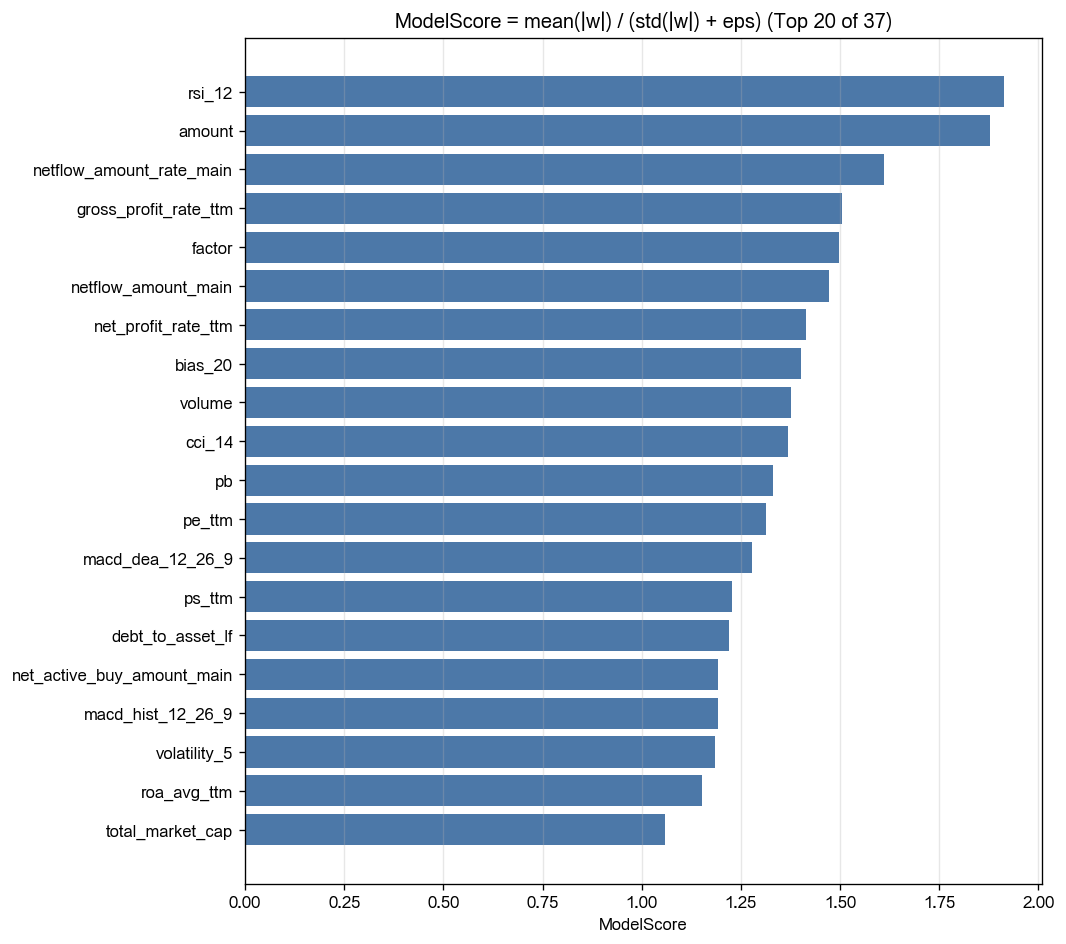
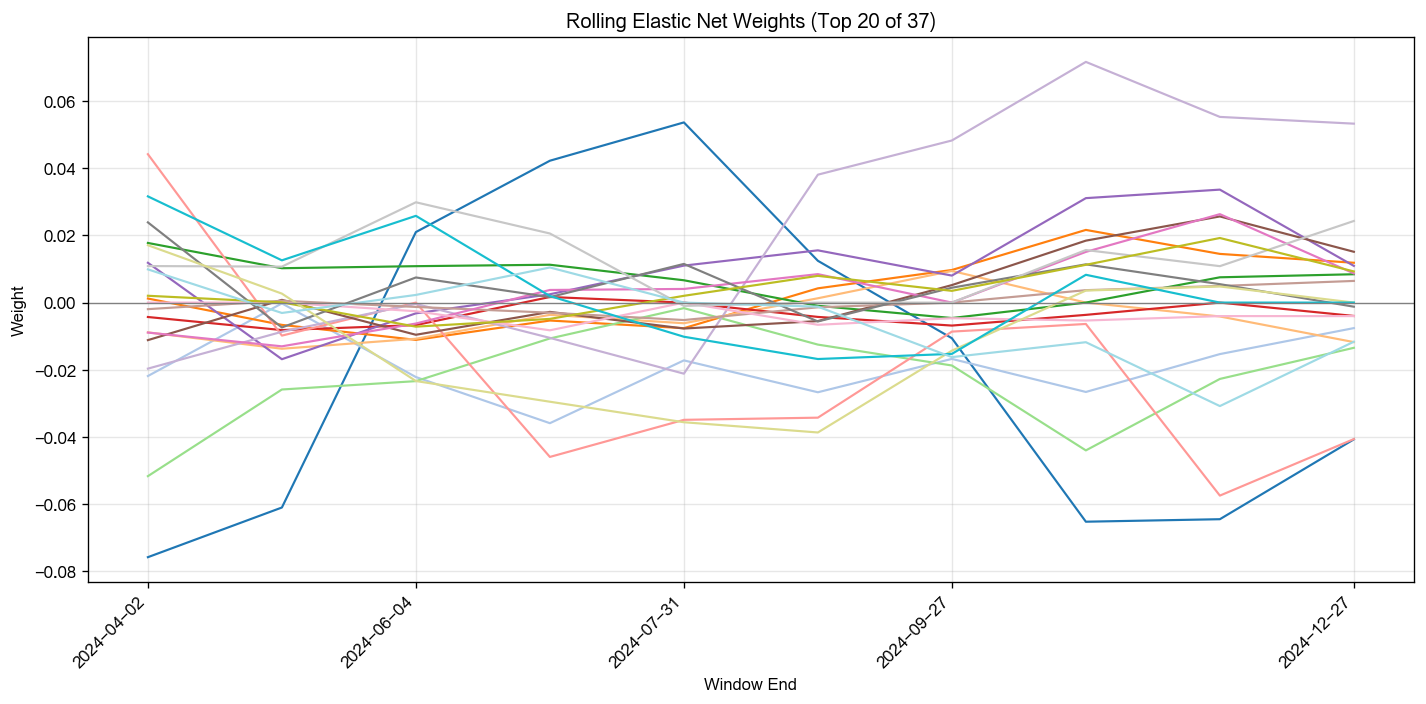
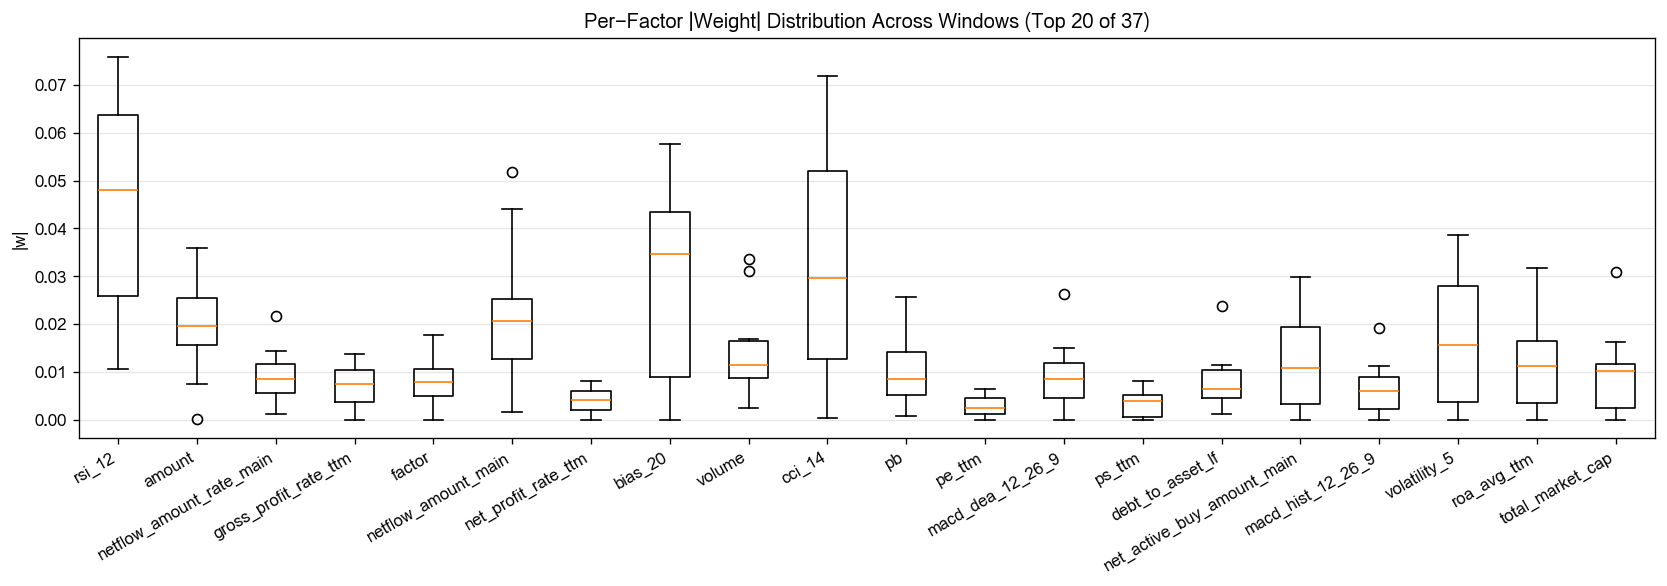
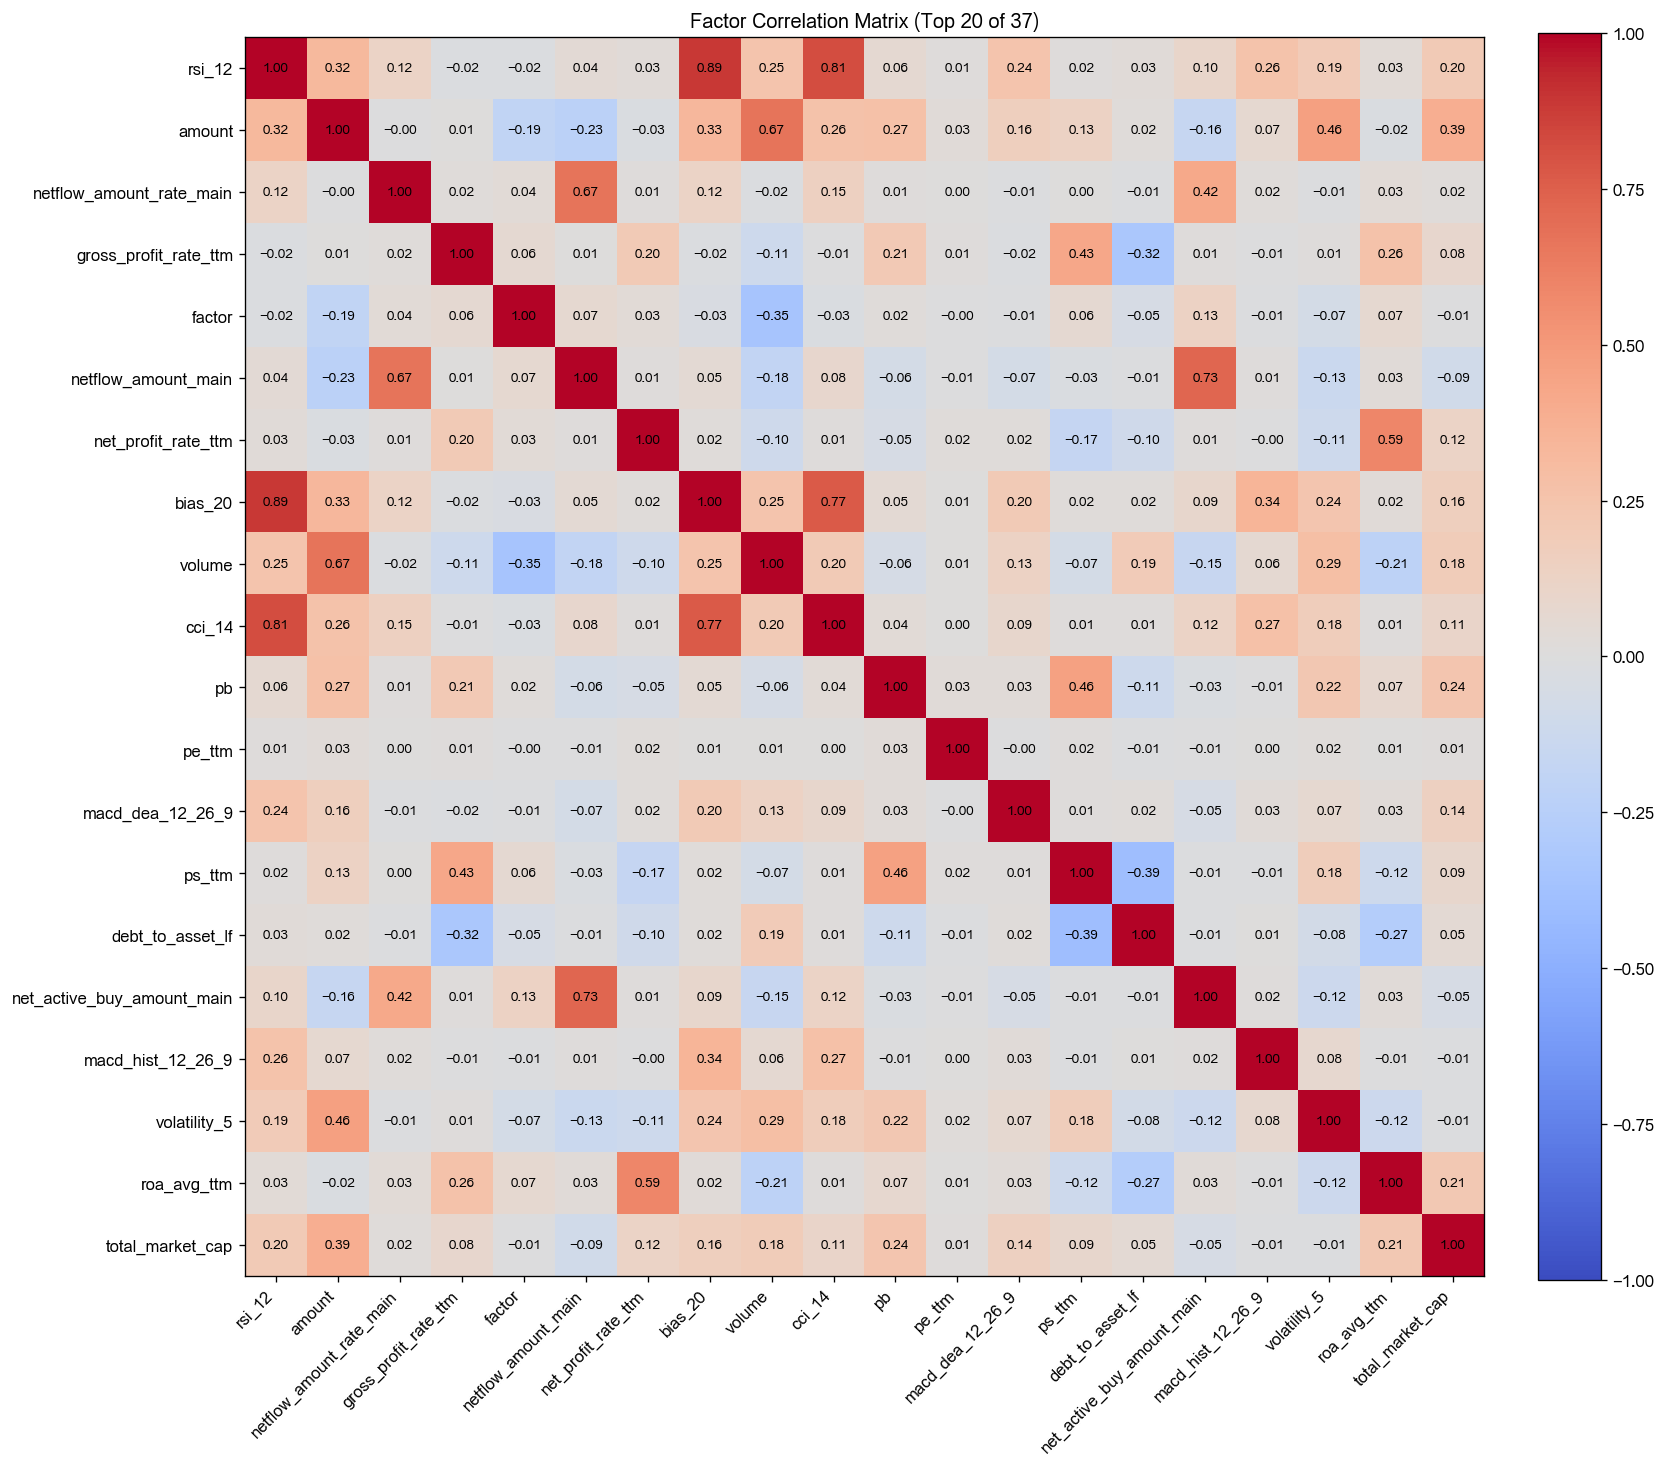

[2026-07-08 15:36:10] [warning  ] 返回的Outputs实例(size=34482125) 大于 64K, 将不会被缓存
[2026-07-08 15:36:10] [info     ] bigalpha_eval.v4 运行完成 [92.042s].


In [1]:
# -*- coding: utf-8 -*-
"""
BigAlpha 2026 传统赛道 — Amihud非流动性与价格冲击非对称因子

投资逻辑:
1. Amihud ILLIQ = |return|/dollar_volume，衡量单位成交额引起的价格变动
2. ILLIQ越高 → 流动性越差 → 投资者要求更高的预期回报（流动性溢价）
3. 价格冲击非对称：上涨冲击远大于下跌冲击 → 卖压重 → 看跌
4. 订单簿深度越大 → 流动性越好 → 预期收益越低（流动性折价）

因子值越大 → 越看好（流动性溢价 + 下跌支撑）
"""

def main(datasources, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=7))

    # 5档加权买卖量表达式
    w_bid = ("COALESCE(bid_volume1,0)*1.0+COALESCE(bid_volume2,0)*EXP(-0.3)"
             "+COALESCE(bid_volume3,0)*EXP(-0.6)+COALESCE(bid_volume4,0)*EXP(-0.9)"
             "+COALESCE(bid_volume5,0)*EXP(-1.2)")
    w_ask = ("COALESCE(ask_volume1,0)*1.0+COALESCE(ask_volume2,0)*EXP(-0.3)"
             "+COALESCE(ask_volume3,0)*EXP(-0.6)+COALESCE(ask_volume4,0)*EXP(-0.9)"
             "+COALESCE(ask_volume5,0)*EXP(-1.2)")
    depth5 = ("COALESCE(bid_volume1,0)+COALESCE(bid_volume2,0)+COALESCE(bid_volume3,0)"
              "+COALESCE(bid_volume4,0)+COALESCE(bid_volume5,0)"
              "+COALESCE(ask_volume1,0)+COALESCE(ask_volume2,0)+COALESCE(ask_volume3,0)"
              "+COALESCE(ask_volume4,0)+COALESCE(ask_volume5,0)")

    sql = f"""
    WITH cte_minute AS (
        SELECT
            date, instrument,
            strftime(date, '%Y-%m-%d') as trading_day,
            (ask_price1 + bid_price1) / 2.0 as mid_price,
            volume, amount,
            -- 5档加权不平衡
            (({w_bid}) - ({w_ask})) / NULLIF(({w_bid}) + ({w_ask}), 0) as w_imb,
            -- 5档总深度
            ({depth5}) as total_depth,
            -- 相对价差
            (ask_price1 - bid_price1) / NULLIF((ask_price1 + bid_price1) / 2.0, 0) as spread
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0 AND amount > 0
    ),
    cte_with_ret AS (
        SELECT *,
            mid_price / NULLIF(lag(mid_price, 1) OVER (
                PARTITION BY instrument, trading_day ORDER BY date), 0) - 1 as mid_ret
        FROM cte_minute
    ),
    cte_daily AS (
        SELECT
            trading_day, instrument,

            -- Amihud ILLIQ (分钟级)
            AVG(ABS(mid_ret) / NULLIF(amount, 0)) as amihud_illq_raw,

            -- 上涨冲击 (买方驱动的价格变动)
            AVG(CASE WHEN mid_ret > 0 THEN ABS(mid_ret) / NULLIF(amount, 0) END) as up_impact,

            -- 下跌冲击 (卖方驱动的价格变动)
            AVG(CASE WHEN mid_ret < 0 THEN ABS(mid_ret) / NULLIF(amount, 0) END) as down_impact,

            -- 加权不平衡均值 + 标准差
            AVG(w_imb)      as imb_mean,
            nanstd(w_imb)   as imb_std,

            -- 价差
            AVG(spread)     as avg_spread,

            -- 总深度（对数）
            LN(AVG(total_depth) + 1) as log_depth,

            -- 成交量（对数）
            LN(SUM(volume) + 1) as log_volume,
            LN(SUM(amount) + 1) as log_amount,

            -- 波动率
            nanstd(mid_ret) as intraday_vol,

            COUNT(*) as n_bars
        FROM cte_with_ret
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 80
    )
    SELECT
        CAST(trading_day AS DATETIME) as date, instrument,
        amihud_illq_raw, up_impact, down_impact,
        imb_mean, imb_std, avg_spread, log_depth,
        log_volume, log_amount, intraday_vol, n_bars
    FROM cte_daily
    ORDER BY date, instrument
    """

    df = dai.query(sql, filters={'date': [query_start, end_date]}, compression=True).df()
    if df.empty:
        raise ValueError("特征提取为空")

    # ---- 子因子计算 ----

    # 子因子1: Amihud ILLIQ（对数变换，消除右偏）
    # ILLIQ越高 → 流动性越差 → 流动性溢价 → 正向信号
    df['sub_illq'] = np.log(df['amihud_illq_raw'] + 1e-12)

    # 子因子2: 价格冲击非对称
    # up/down > 1 → 买方冲击更大 → 上涨阻力 → 看跌
    # 取负号使正信号对齐
    ratio = np.log(df['up_impact'] + 1e-10) - np.log(df['down_impact'] + 1e-10)
    df['sub_asymmetry'] = -np.tanh(ratio)

    # 子因子3: 流动性折价
    # 深度大 → 流动性好 → 预期收益低 → 负向信号
    # 取负号使方向一致
    df['sub_depth_premium'] = -df['log_depth']

    # 子因子4: 不平衡波动（盘口不稳定 → 信息不对称 → 正向信号）
    df['sub_imb_vol'] = df['imb_std'] / (df['imb_mean'].abs() + 0.1)

    # ---- 截面处理 ----
    subs = ['sub_illq', 'sub_asymmetry', 'sub_depth_premium', 'sub_imb_vol']
    for col in subs:
        df[col + '_w'] = df.groupby('date')[col].transform(
            lambda x: x.clip(x.quantile(0.01), x.quantile(0.99)))
        df[col + '_z'] = df.groupby('date')[col + '_w'].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8))

    # ---- 合成 ----
    df['factor'] = (
        0.35 * df['sub_illq_z'] +
        0.30 * df['sub_asymmetry_z'] +
        0.20 * df['sub_depth_premium_z'] +
        0.15 * df['sub_imb_vol_z']
    )
    df['factor'] = df.groupby('date')['factor'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8))

    # ---- 对齐成分股 ----
    df['date'] = pd.to_datetime(df['date'])
    df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]

    stk = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk['date'] = pd.to_datetime(stk['date'])
    df = pd.merge(df, stk, how='inner', on=['date', 'instrument'])

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['factor'])
    return df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai, structlog
    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    sd, ed = '2024-01-01 00:00:00', '2024-12-31 23:59:59'
    factor_data = main(datasources, sd, ed)
    logger.info(f"因子完成: {len(factor_data)}条, {factor_data['date'].nunique()}天")
    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                            filters={'date': [sd, ed]}).df()
    M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool,
                            process_pools=False, show=True)
